[model] walk: /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b01_walk_plateau_2026-02-04_11-56-55_for_play.pth — 3 actor layer(s)
[model] spin: /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b02_spin_plateau_2026-02-04_14-11-09_for_play.pth — 3 actor layer(s)
[model] jump: /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b03_jump_plateau_2026-02-04_15-21-06_for_play.pth — 3 actor layer(s)
[layer 1] walk: alive=150/150 dead=0 K=44
[layer 1] spin: alive=150/150 dead=0 K=44
[layer 1] jump: alive=150/150 dead=0 K=53
[layer 2] walk: alive=99/150 dead=51 K=69
[layer 2] spin: alive=98/150 dead=52 K=57
[layer 2] jump: alive=98/150 dead=52 K=61


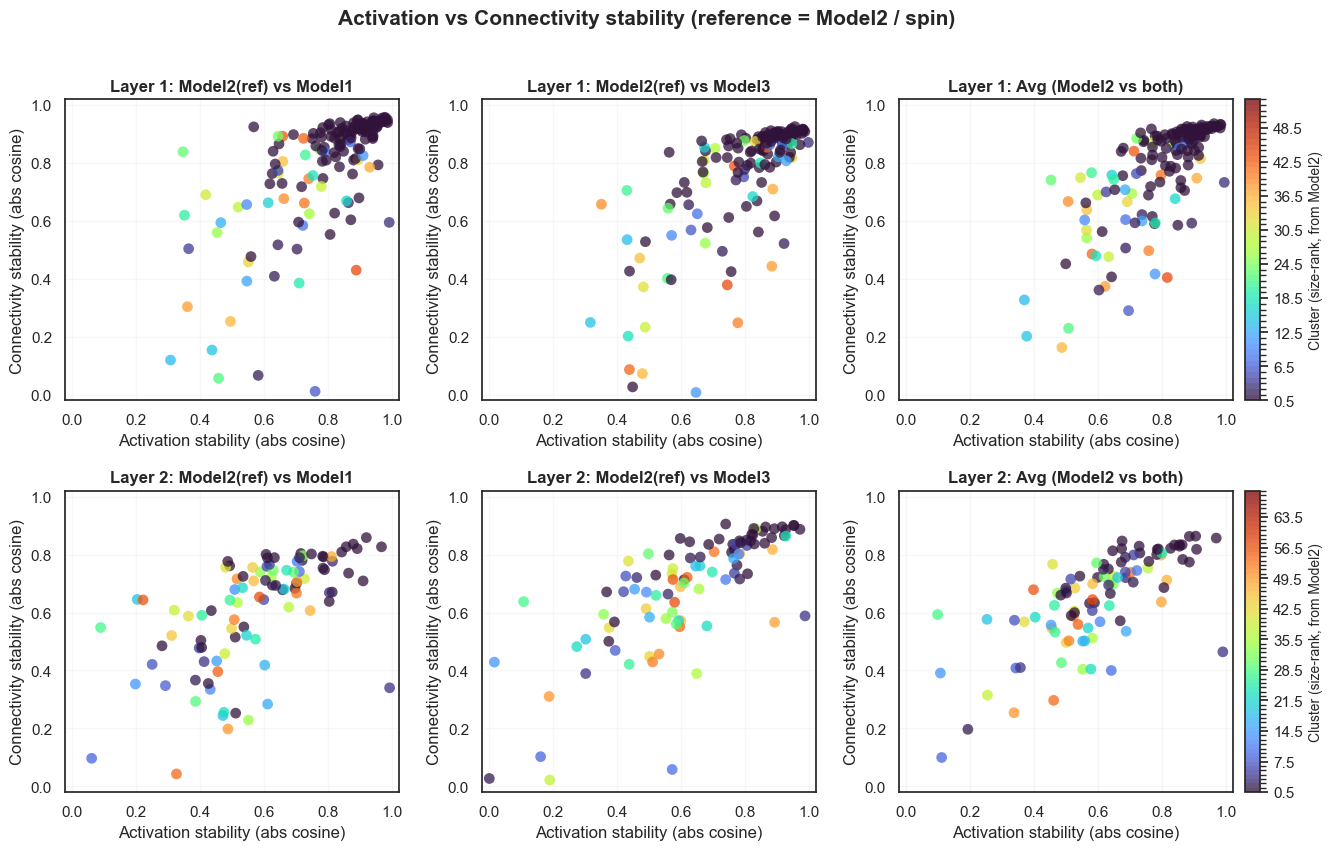

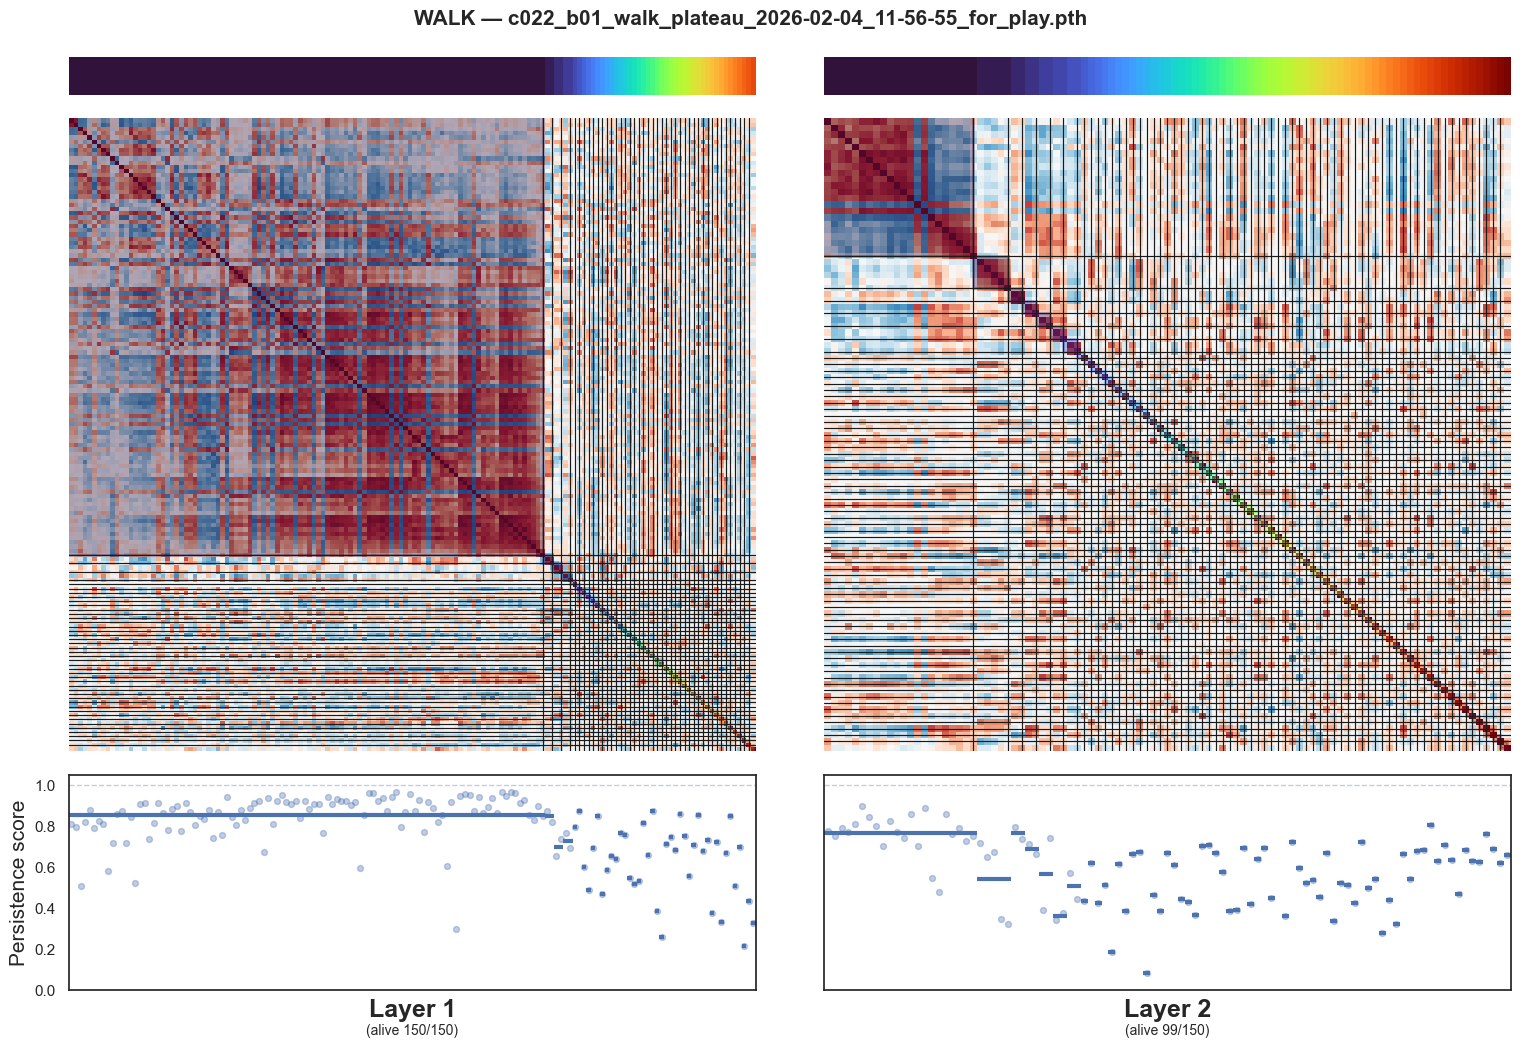

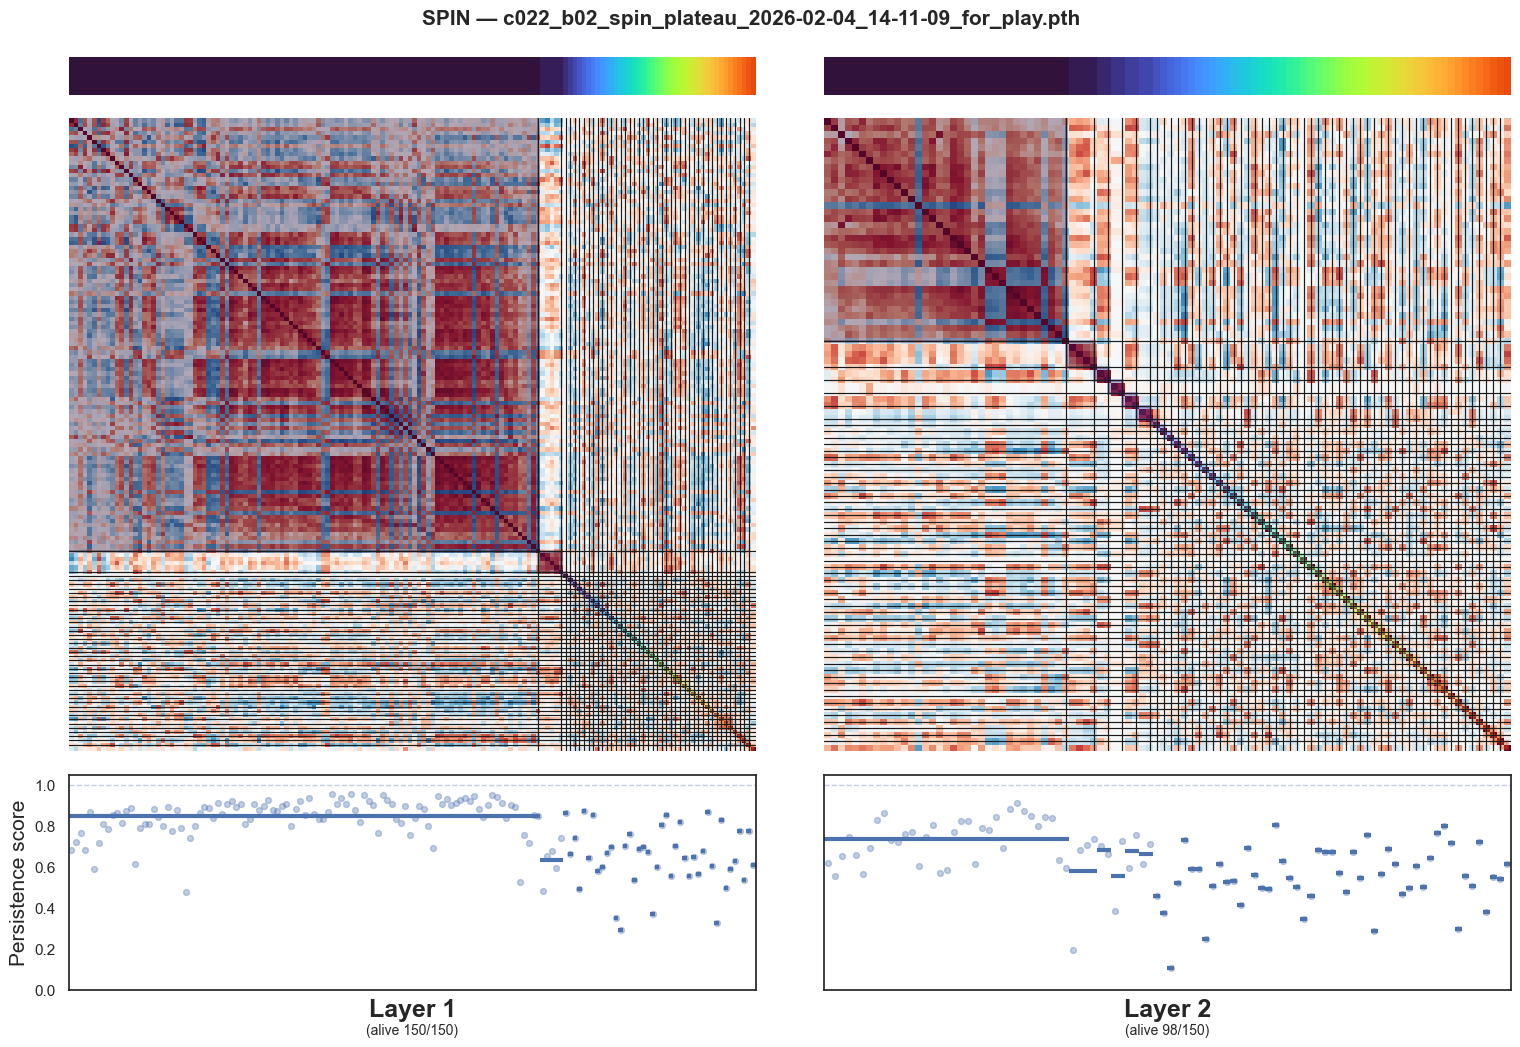

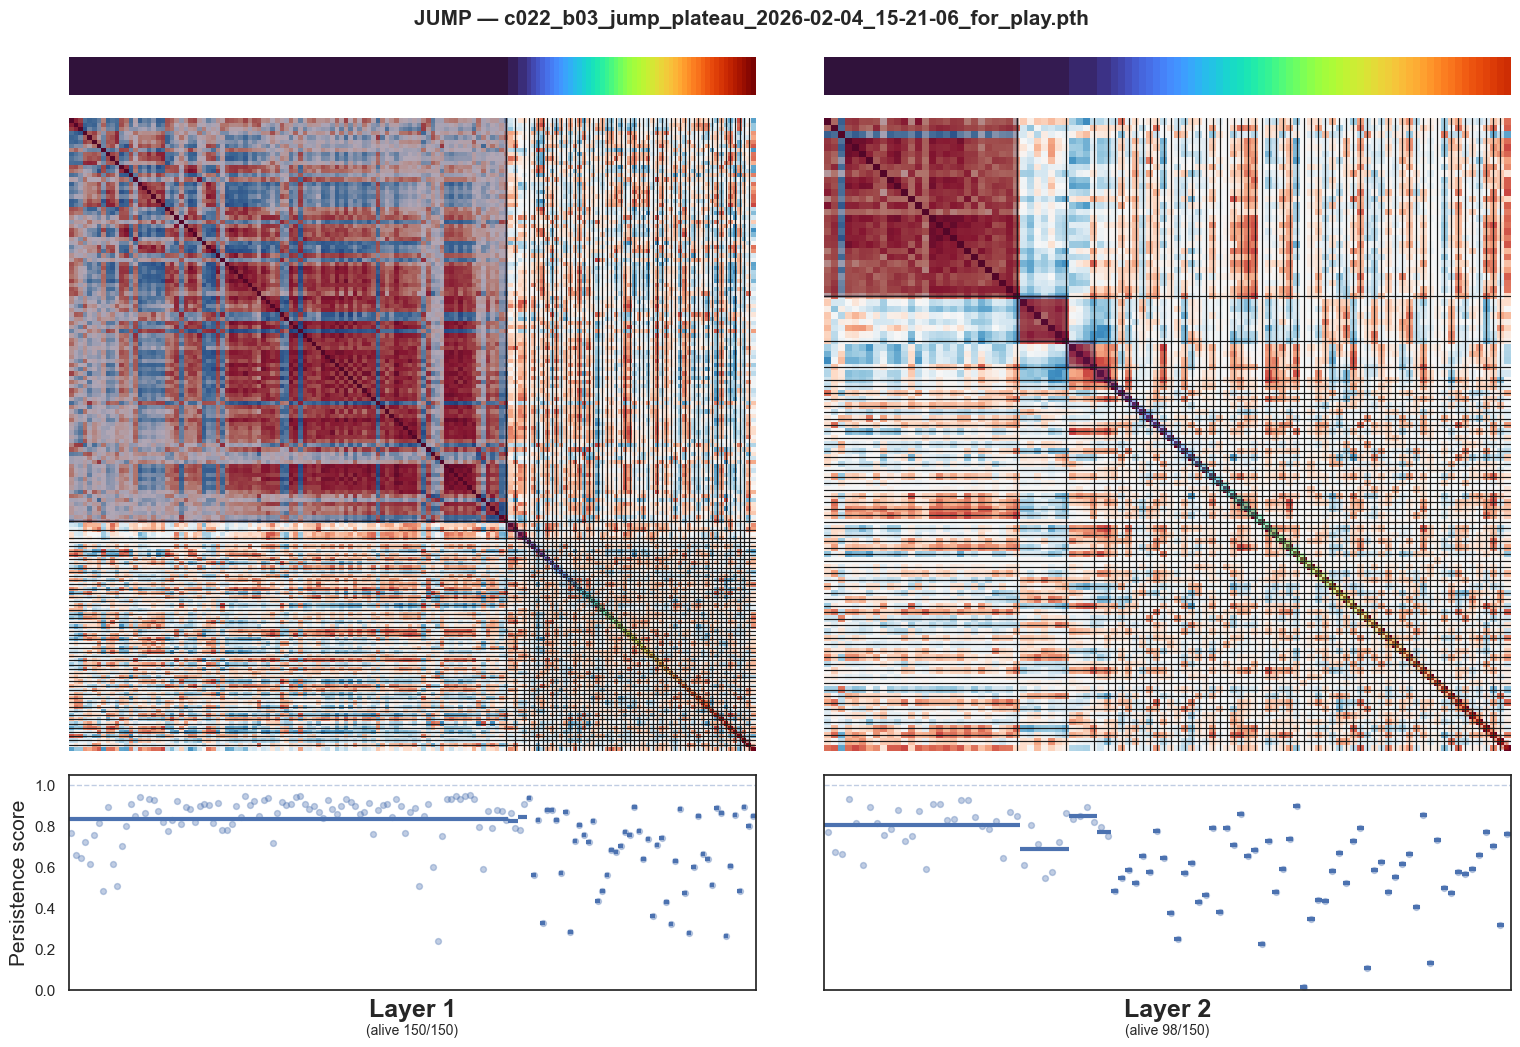

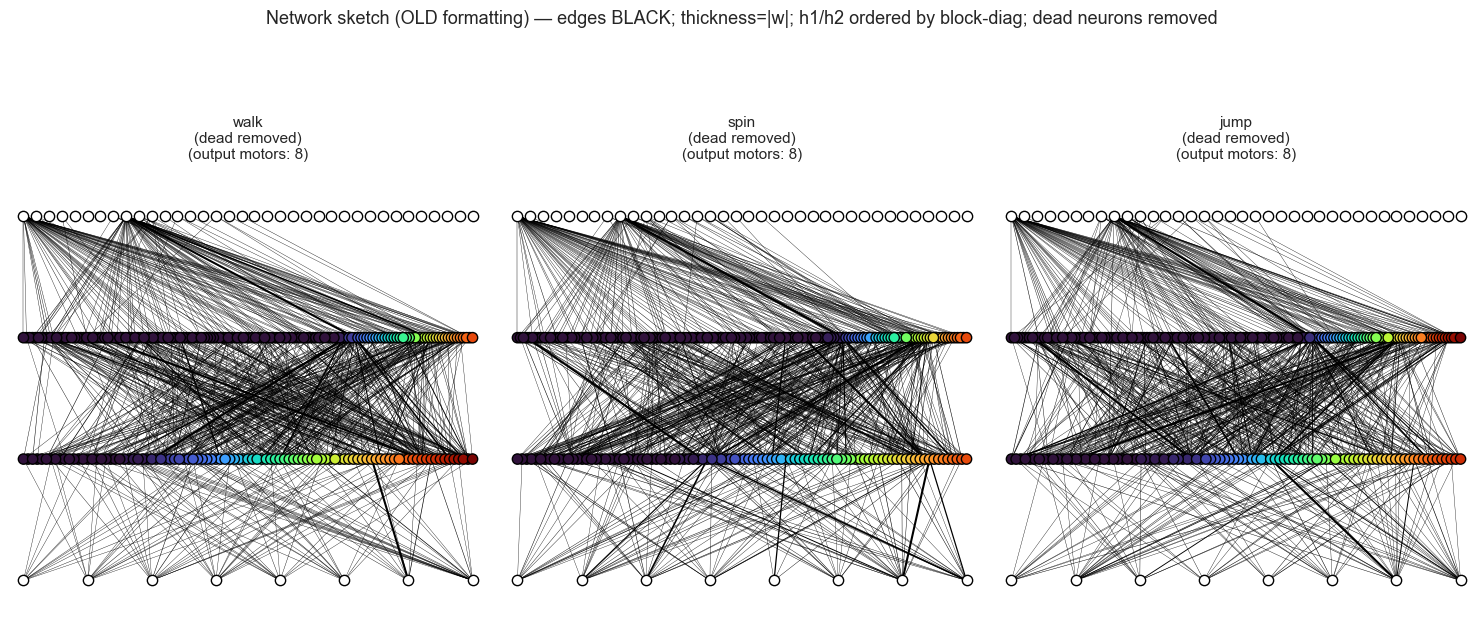

In [2]:
# === Ant Actor (3 models) — Cosine module explorer + Model2-reference stability + OLD-style network sketch (dead neurons removed) ===
# Jupyter SINGLE CELL

from __future__ import annotations

import os, re, math
from pathlib import Path
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import TwoSlopeNorm, BoundaryNorm
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import linkage, optimal_leaf_ordering, fcluster, leaves_list
from scipy.spatial.distance import squareform
from matplotlib import patheffects as pe
from scipy.optimize import linear_sum_assignment

# NEW (required for tau-based block diagonalisation)
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components

# ============================================================
# ========================= CONFIG ===========================
# ============================================================

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "AnalysisScripts":
    REPO_ROOT = REPO_ROOT.parent

# --- REQUIRED: set your 3 model paths here ---
MODEL1_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b01_walk_plateau_2026-02-04_11-56-55_for_play.pth"
MODEL2_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b02_spin_plateau_2026-02-04_14-11-09_for_play.pth"   # reference
MODEL3_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_2_2026-01-30_23-24-40/models/c022_b03_jump_plateau_2026-02-04_15-21-06_for_play.pth"

# # --- REQUIRED: set your 3 model paths here ---
# MODEL1_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/Controls/WSJ_WalkOnly_relu_42_2026-02-01_03-48-47/models/c046_b01_walk_plateau_2026-02-02_12-40-59_for_play.pth"
# MODEL2_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/Controls/WSJ_WalkOnly_relu_42_2026-02-01_03-48-47/models/c047_b01_walk_plateau_2026-02-02_13-21-34_for_play.pth"   # reference
# MODEL3_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/Controls/WSJ_WalkOnly_relu_42_2026-02-01_03-48-47/models/c048_b01_walk_plateau_2026-02-02_14-02-39_for_play.pth"

# --- States pool ---
ALL_STATES_PATH = f"{REPO_ROOT}/Checkpoints_States_selectedGraphs/StatesConcat/ALL_states_concat.npy"
N_ALL_STATES    = 400_000

# --- Layers to analyze (hidden layers) ---
LAYER_INDICES = [0, 1]   # h1=0, h2=1

# --- Similarity / normalization config ---
SEED        = 42
EPS         = 1e-8
MIN_STD     = 1e-5
ACTIVATION  = "relu"     # {"elu","relu","tanh"}

# --- Clustering config (legacy; now unused, kept for compatibility) ---
K_MIN, K_MAX  = 2, 10
ALPHA_SMALL_K = 0.05

# --- NEW: tau-based block diagonalisation config ---
TAU = 0.70
BD_MIN_BLOCK_SIZE = 1

# --- Heatmap visuals ---
CMAP                = "RdBu_r"
VMIN, VCENTER, VMAX = -1.0, 0.0, 1.0

# --- OLD-style network sketch config (vertical, black edges) ---
SKETCH_THRESHOLD_PERCENT_BY_SEG = (97, 97, 85)   # (input→h1, h1→h2, h2→out) percentile on |weights|
SKETCH_MAX_EDGES_PER_SEG = 12000
SKETCH_EDGE_ALPHA_BY_SEG = (1, 1, 1)
SKETCH_LW_SCALE_BY_SEG   = (1.25, 1.25, 1.25)
SKETCH_MAX_LW = 12.0
SKETCH_CIRCLE_SIZE = 100

OUTPUT_MOTORS = 8
OUTPUT_OFFSET = 0



# ============================================================
# ========================= SETUP ============================
# ============================================================

sns.set_theme(style="white", font="Arial")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans"]

def _seed_everything(seed: int):
    import random
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

_seed_everything(SEED)

def _infer_behavior_from_path(p: str) -> str | None:
    s = os.path.basename(p).lower()
    # canonical behaviors we support
    if re.search(r"(^|[^a-z])walk([^a-z]|$)", s) or "_walk_" in s:
        return "walk"
    if re.search(r"(^|[^a-z])(spin|wiggle)([^a-z]|$)", s) or "_spin_" in s or "_wiggle_" in s:
        return "spin"   # canonical = spin (you remap label to wiggle later)
    if re.search(r"(^|[^a-z])(jump|bob)([^a-z]|$)", s) or "_jump_" in s or "_bob_" in s:
        return "jump"   # canonical = jump (you remap label to bob later)
    return None

# detect behaviors from the 3 provided paths (in order: model1, model2, model3)
_raw_paths = [MODEL1_PATH, MODEL2_PATH, MODEL3_PATH]
_raw_behs  = [_infer_behavior_from_path(p) for p in _raw_paths]

# fallback if any path doesn't parse
if any(b is None for b in _raw_behs):
    _raw_behs = ["walk", "spin", "jump"]

# make internal keys unique if duplicates (e.g., walk/walk/walk)
_counts = {b: _raw_behs.count(b) for b in set(_raw_behs)}
_seen = {b: 0 for b in _counts}
_internal = []
for b in _raw_behs:
    _seen[b] += 1
    _internal.append(f"{b}{_seen[b]}" if _counts[b] > 1 else b)

MODEL_PATHS = {k: p for k, p in zip(_internal, _raw_paths)}
MODEL_ORDER = list(_internal)
REF_MODEL   = MODEL_ORDER[1]   # model2 is always reference

# (optional but safe) convenience handles for "first/third" model keys
M1_KEY, M2_KEY, M3_KEY = MODEL_ORDER[0], MODEL_ORDER[1], MODEL_ORDER[2]

for p in list(MODEL_PATHS.values()) + [ALL_STATES_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing path: {p}")

# ============================================================
# ========================= HELPERS ==========================
# ============================================================

def _torch_load_compat(path: str):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")
    except Exception:
        try:
            return torch.load(path, map_location="cpu", weights_only=False)
        except TypeError:
            return torch.load(path, map_location="cpu")

def _load_rlg_forplay_state_dict(path: str) -> dict:
    payload = _torch_load_compat(path)
    if isinstance(payload, dict) and "model" in payload and isinstance(payload["model"], dict):
        sd = {}
        for k, v in payload["model"].items():
            sd[k] = v.detach().cpu().clone() if torch.is_tensor(v) else v
        return sd
    raise ValueError(f"[ckpt] {path} missing 'model' dict (for-play).")

def _discover_actor_mlp_layers(state_dict: dict):
    candidates = []
    for k in state_dict.keys():
        if k.endswith(".weight") and ("actor_mlp" in k or ".actor." in k or "actor_net" in k or "actor.trunk" in k):
            parts = k.split(".")
            try:
                idx = int(parts[-2])
                bias_key = k[:-6] + "bias"
                if bias_key in state_dict:
                    candidates.append((idx, k, bias_key))
            except Exception:
                candidates.append((10**6, k, k[:-6] + "bias"))
    candidates.sort(key=lambda t: (t[0], t[1]))
    return candidates

def _first_linear_in(actor_layers, sd):
    if not actor_layers:
        raise RuntimeError("No actor MLP layers found.")
    _, wkey, _ = actor_layers[0]
    W = sd[wkey]
    if isinstance(W, torch.Tensor):
        W = W.detach().cpu().numpy()
    if W.ndim != 2:
        raise RuntimeError(f"Unexpected weight shape for {wkey}: {tuple(W.shape)}")
    return W.shape[1], W.shape[0]  # in_dim, out_dim

def _activation(x: np.ndarray, name: str) -> np.ndarray:
    if name == "elu":
        y = x.copy()
        neg = x <= 0
        y[neg] = np.expm1(x[neg])
        return y
    if name == "relu":
        return np.maximum(0.0, x)
    if name == "tanh":
        return np.tanh(x)
    raise ValueError(f"Unsupported ACTIVATION '{name}'")

def _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name, max_layers: int = 2):
    outs = []
    h = X
    L = min(max_layers, len(actor_layers))
    for li in range(L):
        _, wkey, bkey = actor_layers[li]
        W = sd[wkey]
        if isinstance(W, torch.Tensor):
            W = W.detach().cpu().numpy()
        b = sd[bkey]
        if isinstance(b, torch.Tensor):
            b = b.detach().cpu().numpy()
        h = h @ W.T + b[None, :]
        h = _activation(h, activation_name)
        outs.append(h.astype(np.float32, copy=False))
    return outs

def get_layer_output_batch_from_ckpt(sd, inputs: torch.Tensor, layer_idx: int, actor_layers, activation_name):
    X = inputs.detach().cpu().numpy().astype(np.float32, copy=False)
    outs = _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name, max_layers=max(LAYER_INDICES)+1)
    if layer_idx < 0 or layer_idx >= len(outs):
        raise IndexError(f"layer_idx={layer_idx} out of range (0..{len(outs)-1})")
    return outs[layer_idx]

def _zscore_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    if X.size == 0:
        return X.astype(np.float32, copy=False)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)

def _dead_alive_indices(acts_post: np.ndarray, min_std: float):
    if acts_post.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    sd = acts_post.std(axis=0)
    dead_mask = sd <= min_std
    dead_idx = np.where(dead_mask)[0].astype(int)
    alive_idx = np.where(~dead_mask)[0].astype(int)
    return dead_idx, alive_idx

def cosine_sim_matrix_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """
    Cosine similarity between columns of X (T,N). Returns (N,N) in [-1,1], diag=1.
    """
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[1]
    if n == 0:
        return np.zeros((0, 0), np.float32)
    if n == 1:
        return np.ones((1, 1), np.float32)

    norms = np.linalg.norm(X, axis=0, keepdims=True)
    norms = np.where(norms < eps, 1.0, norms)
    Xn = X / norms
    R = (Xn.T @ Xn).astype(np.float32, copy=False)
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
    R = np.clip(R, -1.0, 1.0)
    np.fill_diagonal(R, 1.0)
    return R

def _norm01(a):
    a = np.array(a, dtype=np.float64)
    if np.all(np.isnan(a)):
        return np.zeros_like(a)
    lo, hi = np.nanmin(a), np.nanmax(a)
    return np.zeros_like(a) if hi - lo < 1e-12 else (a - lo) / (hi - lo)

def _within_between_stats(R_abs, labels):
    if R_abs.size == 0 or labels.size == 0:
        return dict(within=np.nan, between=np.nan, delta=np.nan)
    same = (labels[:, None] == labels[None, :])
    np.fill_diagonal(same, False)
    within = R_abs[same]
    between = R_abs[~same]
    w = float(within.mean()) if within.size else np.nan
    b = float(between.mean()) if between.size else np.nan
    return dict(within=w, between=b, delta=(w - b) if np.isfinite(w) and np.isfinite(b) else np.nan)

def _modularity_Q_pos(R_abs, labels):
    A = np.clip(R_abs, 0.0, None).astype(np.float64)
    np.fill_diagonal(A, 0.0)
    m = A.sum() / 2.0
    if m <= 0:
        return np.nan
    k = A.sum(axis=1)
    Q = 0.0
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            if labels[i] == labels[j]:
                Q += A[i, j] - (k[i]*k[j] / (2.0*m))
    return float(Q / (2.0*m))

def _cluster_order_and_labels_abs(R_abs, K):
    n = int(R_abs.shape[0])
    if n == 0:
        return np.array([], int), np.array([], int)
    if n < 3:
        order = np.arange(n, dtype=int)
        labels = np.ones(n, dtype=int)
        return order, labels

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)

    D = 1.0 - R_abs
    D = np.clip(D, 0.0, 1.0)
    np.fill_diagonal(D, 0.0)

    y = squareform(D, checks=False)
    Z = linkage(y, method="average")
    Z = optimal_leaf_ordering(Z, y)
    order = leaves_list(Z)
    labels = fcluster(Z, t=K, criterion="maxclust")
    return order, labels

def choose_K_and_order_abs(R_abs, k_min=2, k_max=10, alpha_small_k=0.05):
    n = int(R_abs.shape[0])
    if n == 0:
        return 2, np.array([], int), np.array([], int)
    if n < 3:
        order = np.arange(n, dtype=int)
        labels = np.ones(n, dtype=int)
        return 1, order, labels

    Ks = list(range(max(2, k_min), max(k_min, k_max) + 1))
    deltas, Qs, orders, labels_store = [], [], {}, {}
    for K in Ks:
        order, labels = _cluster_order_and_labels_abs(R_abs, K)
        orders[K] = order
        labels_store[K] = labels
        st = _within_between_stats(R_abs, labels)
        deltas.append(st["delta"])
        Qs.append(_modularity_Q_pos(R_abs, labels))

    dN = _norm01(deltas)
    qN = _norm01(Qs)
    kN = (np.array(Ks) - min(Ks)) / (max(Ks) - min(Ks) + 1e-12)
    score = 0.6*dN + 0.4*qN - alpha_small_k*kN
    K_best = Ks[int(np.nanargmax(score))]
    return K_best, orders[K_best], labels_store[K_best]

def _relabel_clusters_by_size(labels):
    labels = np.asarray(labels)
    if labels.size == 0:
        return labels.astype(int)
    unique_cids, counts = np.unique(labels, return_counts=True)
    order = np.argsort(-counts)
    sorted_cids = unique_cids[order]
    cid_to_rank = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
    return np.array([cid_to_rank[c] for c in labels], dtype=int)

def _order_by_cluster_size(labels, base_order=None):
    labels = np.asarray(labels)
    n = labels.size
    if n == 0:
        return np.arange(0, dtype=int)
    if base_order is None:
        base_order = np.arange(n, dtype=int)
    base_order = np.asarray(base_order)

    unique_cids = np.unique(labels)
    sizes = [int(np.sum(labels == cid)) for cid in unique_cids]
    sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]

    labels_in_base = labels[base_order]
    new_order_list = []
    for cid in sorted_cids:
        new_order_list.append(base_order[labels_in_base == cid])
    return np.concatenate(new_order_list) if new_order_list else np.arange(n, dtype=int)

def _cluster_bounds(labels, order):
    lr = labels[order]
    return [i - 0.5 for i in range(1, len(lr)) if lr[i] != lr[i-1]]

def hungarian_match_cosine(A, B, eps=1e-8):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)
    if A.size == 0 or B.size == 0:
        sim = np.zeros((A.shape[1] if A.ndim == 2 else 0, B.shape[1] if B.ndim == 2 else 0), dtype=np.float32)
        return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)

    nA = np.linalg.norm(A, axis=0, keepdims=True)
    nB = np.linalg.norm(B, axis=0, keepdims=True)
    nA[nA < eps] = 1.0
    nB[nB < eps] = 1.0

    sim = (A.T @ B) / (nA.T @ nB)
    sim = np.nan_to_num(sim).astype(np.float32, copy=False)
    sim = np.clip(sim, -1.0, 1.0)

    i_idx, j_idx = linear_sum_assignment(-sim)
    matched_vals = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
    return sim, i_idx, j_idx, matched_vals

def _safe_cos_abs(a, b, eps: float = 1e-8) -> float:
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()
    if a.size != b.size or a.size == 0:
        return 0.0
    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    if na < eps or nb < eps:
        return 0.0
    c = float(np.dot(a, b) / (na * nb))
    if not np.isfinite(c):
        return 0.0
    c = max(-1.0, min(1.0, c))
    return float(abs(c))

def _overlay_module_boxes(ax, labels_ord, cluster_cmap, cluster_norm, alpha_fill=0.45, edge_alpha=0.90):
    labels_ord = np.asarray(labels_ord, dtype=int)
    if labels_ord.size == 0:
        return
    # contiguous spans
    start = 0
    cur = int(labels_ord[0])
    spans = []
    for i in range(1, labels_ord.size):
        cid = int(labels_ord[i])
        if cid != cur:
            spans.append((cur, start, i - 1))
            cur = cid
            start = i
    spans.append((cur, start, labels_ord.size - 1))

    for cid, a, b in spans:
        color = cluster_cmap(cluster_norm(int(cid)))
        w = (b - a + 1)
        ax.add_patch(Rectangle(
            (a - 0.5, a - 0.5), w, w,
            facecolor=color,
            edgecolor=(color[0], color[1], color[2], edge_alpha),
            linewidth=2.0,
            alpha=alpha_fill,
            zorder=3
        ))

# ============================================================
# ============ NEW: TAU-BASED BLOCK DIAGONALISATION ===========
# ============================================================

def blockdiag_rcm_blocks_from_abs(R_abs: np.ndarray, tau: float, min_block_size: int):
    """
    Keep edges where |cos|>=tau, blocks={connected components}, order=blocks by size + {RCM} inside.
    Returns:
      order (0-based), labels (1-based)
    """
    R_abs = np.asarray(R_abs, dtype=np.float32)
    n = int(R_abs.shape[0])
    if n == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    if n < 3:
        return np.arange(n, dtype=int), np.ones(n, dtype=int)

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)
    np.fill_diagonal(R_abs, 0.0)

    tau = float(max(0.0, min(1.0, tau)))
    A = (R_abs >= tau).astype(np.int8)
    np.fill_diagonal(A, 0)
    G = csr_matrix(A)

    n_comp, comp0 = connected_components(G, directed=False, connection="weak")  # 0-based
    comp = comp0.copy()

    # merge tiny blocks into one misc block
    if min_block_size is not None and int(min_block_size) > 1:
        sizes = np.bincount(comp, minlength=int(n_comp))
        small = np.where(sizes < int(min_block_size))[0]
        if small.size:
            comp[np.isin(comp, small)] = -1
            keep = [c for c in np.unique(comp) if c != -1]
            remap = {c: i for i, c in enumerate(keep)}
            comp2 = np.empty(n, dtype=int)
            for i in range(n):
                c = comp[i]
                comp2[i] = remap[c] if c != -1 else len(keep)
            comp = comp2
            n_comp = int(comp.max()) + 1

    # order blocks by size; {RCM} inside
    sizes = [(c, int(np.sum(comp == c))) for c in range(int(n_comp))]
    sizes.sort(key=lambda t: -t[1])

    parts = []
    for c, _ in sizes:
        idxs = np.where(comp == c)[0]
        if idxs.size <= 2:
            parts.append(idxs)
        else:
            subG = G[idxs][:, idxs]
            sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
            parts.append(idxs[np.asarray(sub_ord, dtype=int)])

    order = np.concatenate(parts).astype(int)
    labels = (comp + 1).astype(int)
    return order, labels

# ============================================================
# ===================== LOAD STATES + MODELS =================
# ============================================================

all_states = np.load(ALL_STATES_PATH)
if all_states.ndim != 2:
    raise ValueError(f"{ALL_STATES_PATH} has shape {all_states.shape}, expected 2D (*, obs_dim)")

# Load models
state_dicts = {}
actor_layers_by_model = {}

for name in MODEL_ORDER:
    sd = _load_rlg_forplay_state_dict(MODEL_PATHS[name])
    layers = _discover_actor_mlp_layers(sd)
    if not layers:
        raise RuntimeError(f"[{name}] no actor layers discovered.")
    state_dicts[name] = sd
    actor_layers_by_model[name] = layers
    print(f"[model] {name}: {MODEL_PATHS[name]} — {len(layers)} actor layer(s)")

# Infer obs_dim from reference
obs_dim, _ = _first_linear_in(actor_layers_by_model[REF_MODEL], state_dicts[REF_MODEL])
if all_states.shape[1] != obs_dim:
    raise ValueError(f"ALL_STATES obs_dim={all_states.shape[1]}, expected {obs_dim}")

# Sample states
n_avail = all_states.shape[0]
n_pick = int(N_ALL_STATES)
idx = np.random.choice(n_avail, size=n_pick, replace=(n_avail < n_pick))
X = all_states[idx].astype(np.float32, copy=False)
ref_inputs = torch.as_tensor(X, dtype=torch.float32, device="cpu")

# ============================================================
# ============ PER-LAYER: ACTIVATIONS, BLOCKS, FAMILIES =======
# ============================================================

layer_data = {layer_idx: {} for layer_idx in LAYER_INDICES}

for layer_idx in LAYER_INDICES:
    for m in MODEL_ORDER:
        acts_full = get_layer_output_batch_from_ckpt(state_dicts[m], ref_inputs, layer_idx, actor_layers_by_model[m], ACTIVATION)
        dead_idx, alive_idx = _dead_alive_indices(acts_full, MIN_STD)

        acts_alive = acts_full[:, alive_idx] if alive_idx.size else acts_full[:, :0]
        A_z = _zscore_cols(acts_alive, eps=EPS) if acts_alive.size else acts_alive.astype(np.float32, copy=False)

        R_signed = cosine_sim_matrix_cols(A_z, eps=EPS)
        R_abs = np.abs(R_signed)

        # NEW: tau-based block diagonalisation (instead of choose_K_and_order_abs)
        order0, labels0 = blockdiag_rcm_blocks_from_abs(R_abs, tau=TAU, min_block_size=BD_MIN_BLOCK_SIZE)
        labels = _relabel_clusters_by_size(labels0)
        order  = _order_by_cluster_size(labels, base_order=order0)
        K_best = int(np.max(labels) if labels.size else 0)

        layer_data[layer_idx][m] = dict(
            acts_full=acts_full,
            alive_total_idx=alive_idx.astype(int),
            dead_total_idx=dead_idx.astype(int),
            A_z=A_z,
            R_signed=R_signed,
            labels=labels.astype(int),
            order=order.astype(int),
            K_best=int(K_best),
        )

        print(f"[layer {layer_idx+1}] {m}: alive={alive_idx.size}/{acts_full.shape[1]} dead={dead_idx.size} K={K_best}")

# Build shared cluster colormaps per layer (consistent across 3 models)
cluster_vis = {}
for layer_idx in LAYER_INDICES:
    all_labels = []
    for m in MODEL_ORDER:
        lab = layer_data[layer_idx][m]["labels"]
        if lab.size:
            all_labels.append(lab)
    if all_labels:
        max_cluster = int(np.max(np.concatenate(all_labels)))
    else:
        max_cluster = 1

    # NEW: allow many many blocks without crashing / truncating at 10
    # (tab20 looks good for <=20; turbo gives many distinct-ish colors beyond that)
    if max_cluster <= 20:
        cmap = plt.get_cmap("tab20", max_cluster)
    else:
        cmap = plt.get_cmap("turbo", max_cluster)

    norm = BoundaryNorm(np.arange(0.5, max_cluster + 1.5, 1.0), max_cluster)
    cluster_vis[layer_idx] = dict(cmap=cmap, norm=norm, max_cluster=max_cluster)

# Compute families + stability with REF_MODEL as reference (per layer)
layer_stability = {}
for layer_idx in LAYER_INDICES:
    A_ref = layer_data[layer_idx][REF_MODEL]["A_z"]
    n_ref = int(A_ref.shape[1])
    if n_ref == 0:
        layer_stability[layer_idx] = None
        continue

    others = [m for m in MODEL_ORDER if m != REF_MODEL]
    o1, o2 = others[0], others[1]

    # Hungarian maps: ref -> other
    _, i1, j1, _ = hungarian_match_cosine(A_ref, layer_data[layer_idx][o1]["A_z"], eps=EPS)
    _, i2, j2, _ = hungarian_match_cosine(A_ref, layer_data[layer_idx][o2]["A_z"], eps=EPS)

    map1 = np.full(n_ref, -1, dtype=int)
    map2 = np.full(n_ref, -1, dtype=int)
    if i1.size:
        map1[i1] = j1
    if i2.size:
        map2[i2] = j2

    good_ref = np.where((map1 >= 0) & (map2 >= 0))[0].astype(int)
    if good_ref.size == 0:
        layer_stability[layer_idx] = None
        continue

    fam_idx_by_model = {
        REF_MODEL: good_ref,
        o1: map1[good_ref].astype(int),
        o2: map2[good_ref].astype(int),
    }

    # Build family activations (aligned columns)
    W_ref = A_ref[:, fam_idx_by_model[REF_MODEL]]
    W_1   = layer_data[layer_idx][o1]["A_z"][:, fam_idx_by_model[o1]]
    W_2   = layer_data[layer_idx][o2]["A_z"][:, fam_idx_by_model[o2]]

    # Connectivity (within-family) per model
    R_ref = cosine_sim_matrix_cols(W_ref, eps=EPS); np.fill_diagonal(R_ref, 0.0)
    R_1   = cosine_sim_matrix_cols(W_1,   eps=EPS); np.fill_diagonal(R_1,   0.0)
    R_2   = cosine_sim_matrix_cols(W_2,   eps=EPS); np.fill_diagonal(R_2,   0.0)

    n_fam = int(good_ref.size)
    act_21  = np.zeros(n_fam, dtype=np.float32)  # ref vs o1
    conn_21 = np.zeros(n_fam, dtype=np.float32)
    act_23  = np.zeros(n_fam, dtype=np.float32)  # ref vs o2
    conn_23 = np.zeros(n_fam, dtype=np.float32)

    for k in range(n_fam):
        act_21[k]  = _safe_cos_abs(W_ref[:, k], W_1[:, k], eps=EPS)
        act_23[k]  = _safe_cos_abs(W_ref[:, k], W_2[:, k], eps=EPS)
        conn_21[k] = _safe_cos_abs(R_ref[k, :], R_1[k, :], eps=EPS)
        conn_23[k] = _safe_cos_abs(R_ref[k, :], R_2[k, :], eps=EPS)

    act_avg  = 0.5 * (act_21  + act_23)
    conn_avg = 0.5 * (conn_21 + conn_23)

    score_ref = 0.5 * (act_avg + conn_avg)
    score_o1  = 0.5 * (act_21  + conn_21)   # persistence vs ref
    score_o2  = 0.5 * (act_23  + conn_23)   # persistence vs ref

    # Colors from REF_MODEL clusters (for these ref-family neurons)
    labels_ref = layer_data[layer_idx][REF_MODEL]["labels"]
    cluster_ids = labels_ref[fam_idx_by_model[REF_MODEL]]

    layer_stability[layer_idx] = dict(
        fam_idx_by_model=fam_idx_by_model,
        act_21=act_21, conn_21=conn_21,
        act_23=act_23, conn_23=conn_23,
        act_avg=act_avg, conn_avg=conn_avg,
        score_by_model={REF_MODEL: score_ref, o1: score_o1, o2: score_o2},
        cluster_ids_ref=cluster_ids.astype(int),
        others=(o1, o2),
    )

# ============================================================
# ===================== PLOT 6 STABILITY GRAPHS ==============
# ============================================================

def _plot_stability_6graphs():
    fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.0))
    fig.subplots_adjust(wspace=0.25, hspace=0.30)

    STABILITY_DOT_SIZE = 60

    for r, layer_idx in enumerate(LAYER_INDICES):
        st = layer_stability[layer_idx]
        if st is None:
            for c in range(3):
                axes[r, c].axis("off")
            continue

        cmap = cluster_vis[layer_idx]["cmap"]
        norm = cluster_vis[layer_idx]["norm"]
        cids = st["cluster_ids_ref"]

        plots = [
            ("Model2(ref) vs Model1", st["act_21"],  st["conn_21"]),
            ("Model2(ref) vs Model3", st["act_23"],  st["conn_23"]),
            ("Avg (Model2 vs both)",  st["act_avg"], st["conn_avg"]),
        ]

        last_sc = None
        for c, (title, x, y) in enumerate(plots):
            ax = axes[r, c]
            last_sc = ax.scatter(
                x, y,
                c=cids, cmap=cmap, norm=norm,
                s=STABILITY_DOT_SIZE,
                alpha=0.75, linewidths=0.0
            )
            ax.set_xlim(-0.02, 1.02)
            ax.set_ylim(-0.02, 1.02)
            ax.grid(True, alpha=0.15)
            ax.set_title(f"Layer {layer_idx+1}: {title}", fontsize=12, fontweight="bold")
            ax.set_xlabel("Activation stability (abs cosine)")
            ax.set_ylabel("Connectivity stability (abs cosine)")

        cb = fig.colorbar(last_sc, ax=axes[r, :].tolist(), fraction=0.018, pad=0.01)
        cb.set_label("Cluster (size-rank, from Model2)", fontsize=10)

    fig.suptitle("Activation vs Connectivity stability (reference = Model2 / spin)", fontsize=15, fontweight="bold", y=0.98)
    plt.show()

_plot_stability_6graphs()

# ============================================================
# ============= PLOT 3 MODEL HEATMAPS (INLINE, NO FILES) =====
# ============================================================

def _plot_one_model_heatmaps_inline(m: str):
    fig = plt.figure(figsize=(15.5, 10.6))
    gs = fig.add_gridspec(
        nrows=3, ncols=2,
        width_ratios=[1.0, 1.0],
        height_ratios=[0.06, 1.0, 0.34],
        wspace=0.10, hspace=0.08
    )

    ax_top0 = fig.add_subplot(gs[0, 0])
    ax_top1 = fig.add_subplot(gs[0, 1])
    ax_hm0  = fig.add_subplot(gs[1, 0])
    ax_hm1  = fig.add_subplot(gs[1, 1])
    ax_sc0  = fig.add_subplot(gs[2, 0])
    ax_sc1  = fig.add_subplot(gs[2, 1])

    for col, layer_idx in enumerate(LAYER_INDICES):
        d = layer_data[layer_idx][m]
        labels = d["labels"]
        order  = d["order"]
        R      = d["R_signed"]
        R_plot = R[np.ix_(order, order)] if R.size else R
        labels_ord = labels[order] if labels.size else labels

        cmapC = cluster_vis[layer_idx]["cmap"]
        normC = cluster_vis[layer_idx]["norm"]

        ax_top = ax_top0 if col == 0 else ax_top1
        ax_hm  = ax_hm0  if col == 0 else ax_hm1
        ax_sc  = ax_sc0  if col == 0 else ax_sc1

        if labels_ord.size:
            sns.heatmap(labels_ord[None, :], ax=ax_top, cmap=cmapC, norm=normC,
                        cbar=False, xticklabels=False, yticklabels=False)
        else:
            ax_top.axis("off")

        if R_plot.size:
            sns.heatmap(
                R_plot, ax=ax_hm,
                cmap=CMAP, vmin=VMIN, vmax=VMAX, center=VCENTER,
                square=False, cbar=False,
                xticklabels=False, yticklabels=False
            )
        else:
            ax_hm.text(0.5, 0.5, "Empty", ha="center", va="center")
            ax_hm.set_xticks([]); ax_hm.set_yticks([])

        if labels_ord.size and R_plot.size:
            _overlay_module_boxes(ax_hm, labels_ord, cmapC, normC, alpha_fill=0.35, edge_alpha=0.85)
            for b in _cluster_bounds(labels, order):
                ax_hm.axhline(b, color="k", lw=0.85, zorder=5)
                ax_hm.axvline(b, color="k", lw=0.85, zorder=5)

        st = layer_stability[layer_idx]
        ax_sc.set_ylim(0.0, 1.05)
        ax_sc.axhline(1.0, ls="--", lw=1.0, alpha=0.35)
        ax_sc.set_xticks([])
        ax_sc.set_xlabel(f"Layer {layer_idx+1}", fontsize=18, fontweight="bold", labelpad=6)
        if col == 0:
            ax_sc.set_ylabel("Persistence score", fontsize=15)
        else:
            ax_sc.set_ylabel("")
            ax_sc.set_yticks([])
            ax_sc.set_yticklabels([])

        if st is None:
            ax_sc.text(0.5, 0.5, "No families", ha="center", va="center", transform=ax_sc.transAxes)
        else:
            scores = st["score_by_model"][m]
            fam_idx = st["fam_idx_by_model"][m]

            n_alive = int(layer_data[layer_idx][m]["A_z"].shape[1])
            score_full = np.full(n_alive, np.nan, dtype=np.float32)
            score_full[fam_idx] = scores

            score_ord = score_full[order]
            x = np.arange(score_ord.size)
            mask = np.isfinite(score_ord)
            if np.any(mask):
                ax_sc.scatter(x[mask], score_ord[mask], s=18, alpha=0.35)
            else:
                ax_sc.text(0.5, 0.5, "No matched units", ha="center", va="center", transform=ax_sc.transAxes)

            if labels_ord.size:
                for cid in np.unique(labels_ord):
                    idxs = np.where(labels_ord == cid)[0]
                    if idxs.size:
                        yvals = score_ord[idxs]
                        yvals = yvals[np.isfinite(yvals)]
                        if yvals.size:
                            ax_sc.hlines(float(yvals.mean()), idxs.min()-0.5, idxs.max()+0.5, linewidth=3.0)

            ax_sc.set_xlim(-0.5, len(score_ord)-0.5)

        alive = int(layer_data[layer_idx][m]["alive_total_idx"].size)
        tot   = int(layer_data[layer_idx][m]["acts_full"].shape[1])
        ax_sc.text(0.5, -0.155, f"(alive {alive}/{tot})", transform=ax_sc.transAxes,
                   ha="center", va="top", fontsize=10)

    fig.suptitle(f"{m.upper()} — {os.path.basename(MODEL_PATHS[m])}", fontsize=15, fontweight="bold", y=0.985)
    fig.subplots_adjust(left=0.06, right=0.99, top=0.94, bottom=0.06)
    plt.show()

for m in MODEL_ORDER:
    _plot_one_model_heatmaps_inline(m)

# ============================================================
# ===== OLD-STYLE NETWORK SKETCH (ONLY SKETCHING CODE; DEAD REMOVED) ====
# ============================================================

def _x_positions_from_order(order: np.ndarray, n: int) -> np.ndarray:
    order = np.asarray(order, dtype=int)
    if order.size != n:
        raise ValueError(f"order size {order.size} != n {n}")
    inv = np.empty(n, dtype=int)
    inv[order] = np.arange(n, dtype=int)
    grid = np.linspace(0.0, 1.0, n)
    return grid[inv]

def _extract_weight_numpy(sd, wkey: str) -> np.ndarray:
    W = sd[wkey]
    if isinstance(W, torch.Tensor):
        W = W.detach().cpu().numpy()
    return np.asarray(W, dtype=np.float32)

def _draw_segment_black_weight(ax, mat, src_x, dst_x, y_src, y_dst,
                               pct: float, alpha: float, lw_scale: float, lw_min: float = 0.25):
    if mat.size == 0:
        return

    mags = np.abs(mat).ravel()
    thr = float(np.percentile(mags, pct)) if mags.size else 0.0
    src_idx, dst_idx = np.where(np.abs(mat) >= thr)

    if src_idx.size == 0:
        flat = np.abs(mat).ravel()
        k = min(SKETCH_MAX_EDGES_PER_SEG, flat.size)
        if k <= 0:
            return
        top = np.argpartition(-flat, k - 1)[:k]
        src_idx, dst_idx = np.unravel_index(top, mat.shape)
    else:
        if src_idx.size > SKETCH_MAX_EDGES_PER_SEG:
            vals = np.abs(mat[src_idx, dst_idx])
            k = SKETCH_MAX_EDGES_PER_SEG
            top = np.argpartition(-vals, k - 1)[:k]
            src_idx = src_idx[top]
            dst_idx = dst_idx[top]

    vals = np.abs(mat[src_idx, dst_idx]).astype(np.float32)
    ord_draw = np.argsort(vals)
    src_idx = src_idx[ord_draw]
    dst_idx = dst_idx[ord_draw]
    vals = vals[ord_draw]

    vmin = float(np.min(vals)) if vals.size else 0.0
    vmax = float(np.max(vals)) if vals.size else 1.0
    denom = (vmax - vmin) + 1e-12

    for si, di, mag in zip(src_idx, dst_idx, vals):
        mag_n = float((mag - vmin) / denom)
        lw = min(lw_min + (mag_n ** 1.5) * lw_scale, SKETCH_MAX_LW)
        ax.plot([src_x[si], dst_x[di]],
                [y_src,     y_dst],
                color=(0.0, 0.0, 0.0, 1.0),
                lw=lw,
                alpha=float(alpha))

def plot_network_sketch_dead_removed():
    for m in MODEL_ORDER:
        if len(actor_layers_by_model[m]) < 3:
            raise RuntimeError(f"[{m}] Need >=3 actor Linear layers for sketch. Found {len(actor_layers_by_model[m])}.")

    num_models = len(MODEL_ORDER)

    fig, axes = plt.subplots(1, num_models, figsize=(5.0 * num_models, 6.5), sharex=False, sharey=False)
    axes = np.atleast_1d(axes)

    NODE_S = max(12, int(SKETCH_CIRCLE_SIZE * 0.55))

    percs   = SKETCH_THRESHOLD_PERCENT_BY_SEG
    alphas  = SKETCH_EDGE_ALPHA_BY_SEG
    lwsc    = SKETCH_LW_SCALE_BY_SEG
    y_levels = {"in": 3.0, "h1": 2.0, "h2": 1.0, "out": 0.0}

    for j, m in enumerate(MODEL_ORDER):
        ax = axes[j]

        layers = actor_layers_by_model[m]
        sd     = state_dicts[m]

        _, w0, _ = layers[0]
        _, w1, _ = layers[1]
        _, w2, _ = layers[2]

        W_in_full  = _extract_weight_numpy(sd, w0)
        W_mid_full = _extract_weight_numpy(sd, w1)
        W_out_full = _extract_weight_numpy(sd, w2)

        alive_h1_total = layer_data[0][m]["alive_total_idx"]
        alive_h2_total = layer_data[1][m]["alive_total_idx"]

        W_in  = W_in_full[alive_h1_total, :]
        W_mid = W_mid_full[alive_h2_total, :][:, alive_h1_total]

        if W_out_full.shape[0] < OUTPUT_OFFSET + OUTPUT_MOTORS:
            raise RuntimeError(
                f"[{m}] Output layer has {W_out_full.shape[0]} rows, cannot slice motors "
                f"[{OUTPUT_OFFSET}:{OUTPUT_OFFSET + OUTPUT_MOTORS}]."
            )
        W_out = W_out_full[OUTPUT_OFFSET:OUTPUT_OFFSET + OUTPUT_MOTORS, :][:, alive_h2_total]

        n_h1, n_in = W_in.shape
        n_h2, n_h1b = W_mid.shape
        n_out, n_h2b = W_out.shape
        if n_h1b != n_h1 or n_h2b != n_h2:
            raise RuntimeError(f"[{m}] weight shape mismatch after dead-removal.")

        x_in  = np.linspace(0.0, 1.0, n_in)
        x_out = np.linspace(0.0, 1.0, n_out)

        order_h1 = layer_data[0][m]["order"]
        order_h2 = layer_data[1][m]["order"]
        if order_h1.size != n_h1 or order_h2.size != n_h2:
            raise RuntimeError(f"[{m}] order size mismatch after dead-removal (did alive sets change?)")

        x_h1 = _x_positions_from_order(order_h1, n_h1)
        x_h2 = _x_positions_from_order(order_h2, n_h2)

        cmap0, norm0 = cluster_vis[0]["cmap"], cluster_vis[0]["norm"]
        cmap1, norm1 = cluster_vis[1]["cmap"], cluster_vis[1]["norm"]
        labels_h1 = layer_data[0][m]["labels"]
        labels_h2 = layer_data[1][m]["labels"]

        cols0 = cmap0(norm0(labels_h1)) if labels_h1.size == n_h1 else np.tile(np.array([[0.8,0.8,0.8,1.0]]), (n_h1,1))
        cols1 = cmap1(norm1(labels_h2)) if labels_h2.size == n_h2 else np.tile(np.array([[0.8,0.8,0.8,1.0]]), (n_h2,1))

        M_in  = W_in.T
        M_mid = W_mid.T
        M_out = W_out.T

        _draw_segment_black_weight(ax, M_in,  x_in, x_h1, y_levels["in"],  y_levels["h1"], percs[0], alphas[0], lwsc[0], lw_min=0.25)
        _draw_segment_black_weight(ax, M_mid, x_h1, x_h2, y_levels["h1"], y_levels["h2"], percs[1], alphas[1], lwsc[1], lw_min=0.25)
        _draw_segment_black_weight(ax, M_out, x_h2, x_out, y_levels["h2"], y_levels["out"], percs[2], alphas[2], lwsc[2], lw_min=0.25)

        ax.scatter(x_in,  np.full(n_in,  y_levels["in"]),  s=NODE_S, edgecolor="black", facecolor="white", zorder=3)
        ax.scatter(x_h1,  np.full(n_h1, y_levels["h1"]),  s=NODE_S, color=cols0, edgecolor="black", zorder=3)
        ax.scatter(x_h2,  np.full(n_h2, y_levels["h2"]),  s=NODE_S, color=cols1, edgecolor="black", zorder=3)
        ax.scatter(x_out, np.full(n_out, y_levels["out"]), s=NODE_S, edgecolor="black", facecolor="white", zorder=3)

        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(-0.4, 3.4)
        ax.set_title(f"{m}\n(dead removed)\n(output motors: {OUTPUT_MOTORS})", fontsize=11)
        ax.axis("off")

    fig.suptitle(
        "Network sketch (OLD formatting) — edges BLACK; thickness=|w|; h1/h2 ordered by block-diag; dead neurons removed",
        fontsize=13
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

plot_network_sketch_dead_removed()

[done] Computed eigenspectra using mode='abs'
pooled_region_df contains one row for self and one row for pooled task, per model/layer.


,layer,model,region,size,trace,lambda1,lambda2,eigengap12,lambda1_over_trace,lambda1_over_n,...,eig_11,eig_12,eig_13,eig_14,eig_15,eig_16,eig_17,eig_18,eig_19,eig_20
0,1,jump,self,96,96.0,45.515933,10.521983,34.993950,0.474124,0.474124,...,1.652358,1.547022,1.281192,1.138155,1.026937,0.947228,0.923874,0.862248,0.729742,0.692210
1,1,jump,task_pooled,54,54.0,11.845938,3.472323,8.373615,0.219369,0.219369,...,1.738446,1.630270,1.619258,1.315841,1.252371,1.210039,1.186071,1.109211,1.036870,1.010666
2,1,spin,self,103,103.0,50.344060,10.752721,39.591339,0.488777,0.488777,...,1.625435,1.410532,1.352807,1.240182,1.099652,0.992202,0.928664,0.849493,0.757299,0.713076
3,1,spin,task_pooled,47,47.0,10.321289,3.800539,6.520750,0.219602,0.219602,...,1.541060,1.333750,1.273370,1.143730,1.074488,1.038144,1.007714,0.983178,0.923191,0.837832
4,1,walk,self,104,104.0,51.336594,10.850715,40.485880,0.493621,0.493621,...,1.528430,1.422872,1.168808,1.092269,0.922679,0.877809,0.847264,0.824261,0.756843,0.718117
5,1,walk,task_pooled,46,46.0,9.878045,3.368564,6.509481,0.214740,0.214740,...,1.506823,1.431606,1.306941,1.245377,1.180513,1.061144,0.966825,0.907366,0.861005,0.777011
6,2,jump,self,28,28.0,17.811583,2.310860,15.500723,0.636128,0.636128,...,0.244584,0.217967,0.199801,0.133665,0.126733,0.112366,0.104468,0.085508,0.077289,0.065598
7,2,jump,task_pooled,70,70.0,14.664323,4.594501,10.069823,0.209490,0.209490,...,1.880708,1.811993,1.696835,1.591686,1.464250,1.392288,1.317570,1.239292,1.193662,1.157316
8,2,spin,self,35,35.0,18.171547,5.316636,12.854911,0.519187,0.519187,...,0.484005,0.406753,0.363425,0.307094,0.294156,0.226939,0.204928,0.175975,0.159248,0.151003
9,2,spin,task_pooled,63,63.0,13.306790,4.288226,9.018564,0.211219,0.211219,...,1.756743,1.700937,1.625326,1.443968,1.312925,1.227223,1.171331,1.128950,1.078101,1.004799



[compact summary]


,layer,model,region,size,lambda1,lambda2,eigengap12,lambda1_over_trace,lambda1_over_n,effective_rank
0,1,jump,self,96,45.515933,10.521983,34.993950,0.474124,0.474124,11.320249
1,1,jump,task_pooled,54,11.845938,3.472323,8.373615,0.219369,0.219369,24.123996
2,1,spin,self,103,50.344060,10.752721,39.591339,0.488777,0.488777,11.038095
3,1,spin,task_pooled,47,10.321289,3.800539,6.520750,0.219602,0.219602,22.050864
4,1,walk,self,104,51.336594,10.850715,40.485880,0.493621,0.493621,10.458021
5,1,walk,task_pooled,46,9.878045,3.368564,6.509481,0.214740,0.214740,22.644943
6,2,jump,self,28,17.811583,2.310860,15.500723,0.636128,0.636128,4.854554
7,2,jump,task_pooled,70,14.664323,4.594501,10.069823,0.209490,0.209490,29.833503
8,2,spin,self,35,18.171547,5.316636,12.854911,0.519187,0.519187,6.924318
9,2,spin,task_pooled,63,13.306790,4.288226,9.018564,0.211219,0.211219,26.702576


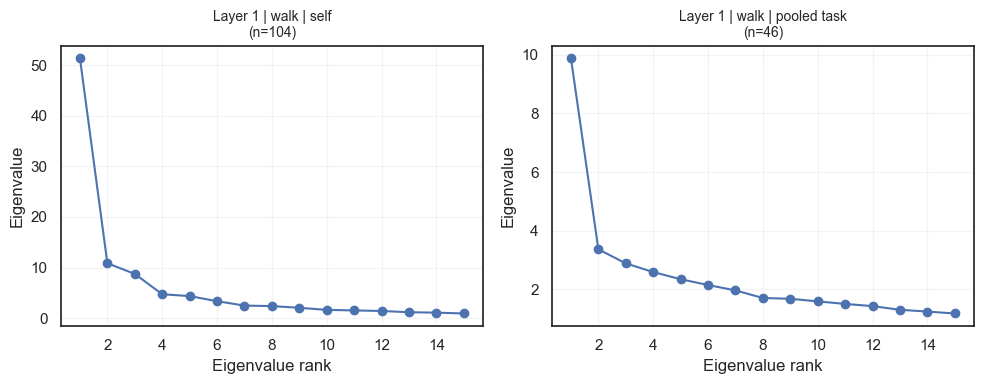

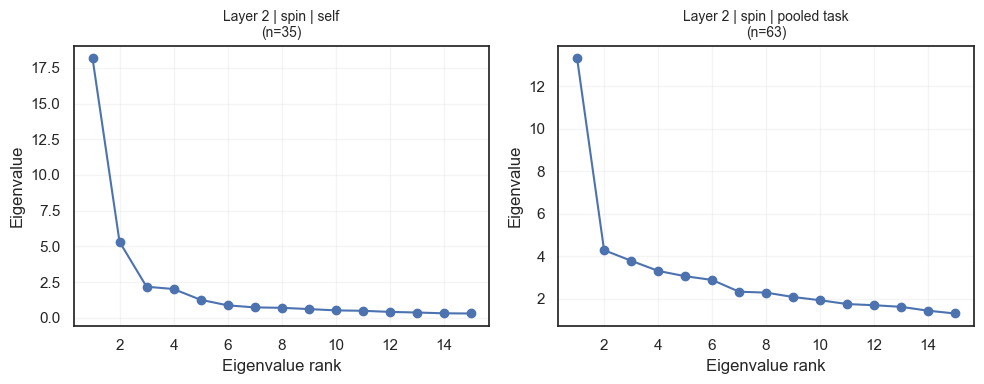

In [4]:
# ============================================================
# ========= SELF BLOCK vs POOLED TASK BLOCK EIGENSPECTRA =====
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
# Use |R| by default, since your blocks are defined from |R| thresholding.
EV_MATRIX_MODE = "abs"   # {"abs", "signed"}

TOP_K_TO_STORE = 20


# ------------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------------
def _get_matrix_for_region_eigs(layer_dict: dict, mode: str = "abs") -> np.ndarray:
    """
    Returns the matrix used for eigendecomposition.
    mode="abs"    -> |R_signed|
    mode="signed" -> symmetrized R_signed
    """
    R_signed = np.asarray(layer_dict["R_signed"], dtype=np.float64)
    R_signed = 0.5 * (R_signed + R_signed.T)

    if mode == "abs":
        M = np.abs(R_signed)
    elif mode == "signed":
        M = R_signed.copy()
    else:
        raise ValueError(f"Unknown mode={mode!r}; expected 'abs' or 'signed'.")

    M = 0.5 * (M + M.T)
    return M


def _safe_eigvals_sym(B: np.ndarray) -> np.ndarray:
    """
    Eigenvalues of a symmetric matrix, sorted descending.
    """
    B = np.asarray(B, dtype=np.float64)
    if B.size == 0:
        return np.array([], dtype=np.float64)
    B = 0.5 * (B + B.T)
    vals = np.linalg.eigvalsh(B)   # ascending
    return np.sort(vals)[::-1]     # descending


def _effective_rank(vals: np.ndarray, eps: float = 1e-12) -> float:
    """
    Effective rank from nonnegative spectrum.
    """
    vals = np.asarray(vals, dtype=np.float64)
    vals = vals[np.isfinite(vals)]
    vals = np.clip(vals, 0.0, None)
    s = vals.sum()
    if s <= eps:
        return np.nan
    p = vals / s
    p = p[p > eps]
    H = -np.sum(p * np.log(p))
    return float(np.exp(H))


def _region_summary(region_name: str, B: np.ndarray, eigvals: np.ndarray, top_k: int = 20) -> dict:
    n = int(B.shape[0])

    trace = float(np.trace(B)) if B.size else np.nan
    lam1 = float(eigvals[0]) if eigvals.size >= 1 else np.nan
    lam2 = float(eigvals[1]) if eigvals.size >= 2 else np.nan
    eigengap12 = (lam1 - lam2) if np.isfinite(lam1) and np.isfinite(lam2) else np.nan

    lam1_over_trace = (lam1 / trace) if np.isfinite(trace) and trace > 1e-12 else np.nan
    lam1_over_n = (lam1 / n) if n > 0 and np.isfinite(lam1) else np.nan
    eff_rank = _effective_rank(eigvals)

    topk = np.full(top_k, np.nan, dtype=np.float64)
    take = min(top_k, eigvals.size)
    if take > 0:
        topk[:take] = eigvals[:take]

    out = {
        "region": region_name,
        "size": n,
        "trace": trace,
        "lambda1": lam1,
        "lambda2": lam2,
        "eigengap12": eigengap12,
        "lambda1_over_trace": lam1_over_trace,
        "lambda1_over_n": lam1_over_n,
        "effective_rank": eff_rank,
        "eigvals": eigvals.copy(),
        "matrix": B.copy(),
    }
    for k in range(top_k):
        out[f"eig_{k+1}"] = topk[k]
    return out


# ------------------------------------------------------------------
# MAIN COMPUTATION
# ------------------------------------------------------------------
pooled_region_results = {}   # pooled_region_results[layer_idx][model]["self"/"task"]
pooled_region_rows = []

for layer_idx in LAYER_INDICES:
    pooled_region_results[layer_idx] = {}

    for m in MODEL_ORDER:
        d = layer_data[layer_idx][m]
        labels = np.asarray(d["labels"], dtype=int)

        # block 1 = largest block = self
        self_idx = np.where(labels == 1)[0]
        task_idx = np.where(labels != 1)[0]

        M = _get_matrix_for_region_eigs(d, mode=EV_MATRIX_MODE)

        pooled_region_results[layer_idx][m] = {}

        # ---------------- SELF ----------------
        B_self = M[np.ix_(self_idx, self_idx)] if self_idx.size else np.zeros((0, 0), dtype=np.float64)
        ev_self = _safe_eigvals_sym(B_self)
        self_info = _region_summary("self", B_self, ev_self, top_k=TOP_K_TO_STORE)
        pooled_region_results[layer_idx][m]["self"] = self_info

        # ---------------- TASK (POOLED) ----------------
        B_task = M[np.ix_(task_idx, task_idx)] if task_idx.size else np.zeros((0, 0), dtype=np.float64)
        ev_task = _safe_eigvals_sym(B_task)
        task_info = _region_summary("task_pooled", B_task, ev_task, top_k=TOP_K_TO_STORE)
        pooled_region_results[layer_idx][m]["task_pooled"] = task_info

        for region_name, info in [("self", self_info), ("task_pooled", task_info)]:
            row = {
                "layer": int(layer_idx + 1),
                "model": str(m),
                "region": region_name,
                "size": info["size"],
                "trace": info["trace"],
                "lambda1": info["lambda1"],
                "lambda2": info["lambda2"],
                "eigengap12": info["eigengap12"],
                "lambda1_over_trace": info["lambda1_over_trace"],
                "lambda1_over_n": info["lambda1_over_n"],
                "effective_rank": info["effective_rank"],
            }
            for k in range(TOP_K_TO_STORE):
                row[f"eig_{k+1}"] = info[f"eig_{k+1}"]
            pooled_region_rows.append(row)

pooled_region_df = pd.DataFrame(pooled_region_rows).sort_values(
    ["layer", "model", "region"]
).reset_index(drop=True)

print(f"[done] Computed eigenspectra using mode={EV_MATRIX_MODE!r}")
print("pooled_region_df contains one row for self and one row for pooled task, per model/layer.")
display(pooled_region_df)


# ------------------------------------------------------------------
# OPTIONAL: print compact comparison
# ------------------------------------------------------------------
compact_cols = [
    "layer", "model", "region", "size",
    "lambda1", "lambda2", "eigengap12",
    "lambda1_over_trace", "lambda1_over_n", "effective_rank"
]
print("\n[compact summary]")
display(pooled_region_df[compact_cols])


# ------------------------------------------------------------------
# OPTIONAL: scree plots for self vs pooled task
# ------------------------------------------------------------------
def plot_self_vs_task_scree(layer_idx: int, model_name: str, max_eigs_to_show: int = 20):
    """
    Plot scree curves for self block and pooled task block for one model/layer.
    layer_idx is 0-based (same convention as layer_data / LAYER_INDICES).
    """
    if layer_idx not in pooled_region_results:
        raise KeyError(f"Unknown layer_idx={layer_idx}")
    if model_name not in pooled_region_results[layer_idx]:
        raise KeyError(f"Unknown model={model_name!r} for layer_idx={layer_idx}")

    info_self = pooled_region_results[layer_idx][model_name]["self"]
    info_task = pooled_region_results[layer_idx][model_name]["task_pooled"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, title, info in zip(
        axes,
        [f"Layer {layer_idx+1} | {model_name} | self", f"Layer {layer_idx+1} | {model_name} | pooled task"],
        [info_self, info_task]
    ):
        vals = info["eigvals"][:max_eigs_to_show]
        x = np.arange(1, len(vals) + 1)

        ax.plot(x, vals, marker="o")
        ax.set_title(f"{title}\n(n={info['size']})", fontsize=10)
        ax.set_xlabel("Eigenvalue rank")
        ax.set_ylabel("Eigenvalue")
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


# Example usage:
plot_self_vs_task_scree(layer_idx=0, model_name=MODEL_ORDER[0], max_eigs_to_show=15)
plot_self_vs_task_scree(layer_idx=1, model_name=MODEL_ORDER[1], max_eigs_to_show=15)